In [ ]:
print("howdy, world!")

howdy, world!


In [ ]:
# https://www.epa.gov/outdoor-air-quality-data/download-daily-data - Air Quality

# https://firms.modaps.eosdis.nasa.gov/download/ (MODIS) - Fire Location/Intensity (Need to only care for LA)

# Open-Meteo API Pull - Wind Data

In [ ]:
!pip install openmeteo-requests requests-cache pandas retry-requests pydeck # (pydeck newly added!)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 62.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.6/208.6 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 718.0/718.0 kB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.8/138.8 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 399.4/399.4 kB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 82.1 MB/s eta 0:00:00
  Attempting uninstall: flatbuffers
    Found existing installation: flatbuffers 25.12.19
    Uninstalling flatbuffers-25.12.19:
      Successfully uninstalled flatbuffers-25.12.19


In [ ]:
import openmeteo_requests
import requests_cache
import pandas as pd
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# COORDINATES FOR LOS ANGELES
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
	"latitude": 34.0549,
	"longitude": -118.2426,
	"start_date": "2025-01-01",
	"end_date": "2025-12-31",
	"daily": ["wind_speed_10m_max", "wind_direction_10m_dominant"]
}

responses = openmeteo.weather_api(url, params=params)
response = responses[0]

# Process daily data
daily = response.Daily()
daily_wind_speed = daily.Variables(0).ValuesAsNumpy()
daily_wind_dir = daily.Variables(1).ValuesAsNumpy()

# Creating the DataFrame
date_range = pd.date_range(
	start = pd.to_datetime(daily.Time(), unit = "s", utc = True),
	end = pd.to_datetime(daily.TimeEnd(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = daily.Interval()),
	inclusive = "left"
)

weather_df = pd.DataFrame({
    "date": date_range,
    "wind_speed": daily_wind_speed,
    "wind_dir": daily_wind_dir
})

# Saving it to file
weather_df.to_csv("la_weather_history.csv", index=False)
print("Data downloaded!")

Data downloaded!


In [ ]:
# Two Approaches

# - Feed-Forward Neural Network (Need to Normalize Values) OR LSTMs
# - Supervised Time-Series Regression - ARIMA (Autoregressive Integrated Moving Average)

In [ ]:
!pwd # To see where you need to drag and drop the data if you get lost in the filesystem

/content


In [ ]:
import pandas as pd
from statsmodels.tsa.stattools import adfuller

df = pd.read_csv("ad_viz_plotval_data.csv")
#df_orange = df[df["County"] == "Orange"]
series = df["Daily Mean PM2.5 Concentration"].dropna()
result = adfuller(series)
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

# because the p-value is so we have a d value of 0

ADF Statistic: -9.82149795165494
p-value: 5.323176303785697e-17
Critical Values: {'1%': np.float64(-3.431640965913047), '5%': np.float64(-2.862110469020709), '10%': np.float64(-2.5670736610619644)}


In [ ]:
import pandas as pd
import statsmodels
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
#df = pd.read_csv("/content/ad_viz_plotval_data (1).csv")
df = pd.read_csv("ad_viz_plotval_data.csv")
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
site_id = "060374010"
one = df[df["Site ID"].astype(str).eq(site_id)].copy()

weekly = (
    df[df["Site ID"] == site_id]
    .groupby(pd.Grouper(key="Date", freq="W"))
    .mean(numeric_only=True)
    .reset_index()
)

weekly.head()

x = df["Daily Mean PM2.5 Concentration"]

statsmodels.tsa.stattools.acf(x, adjusted=False, nlags=None, qstat=False, fft=True, alpha=None, bartlett_confint=True, missing='none')

array([1.        , 0.60571138, 0.37184637, 0.28738143, 0.23444359,
       0.23682855, 0.22032912, 0.24147299, 0.22675118, 0.17930764,
       0.1445005 , 0.10285307, 0.06860287, 0.08810878, 0.12650005,
       0.15198166, 0.14793088, 0.13732304, 0.1438925 , 0.14160458,
       0.12384299, 0.1296831 , 0.13813779, 0.12632091, 0.1322692 ,
       0.09920284, 0.07178955, 0.06724379, 0.06872514, 0.0842407 ,
       0.08450801, 0.08012918, 0.07344896, 0.04968207, 0.06473056,
       0.06107994, 0.06307618, 0.07104421])

First 5 Site IDs found in file: [60370016 60371103 60371201 60371302 60371602]
Number of weekly data points found: 53


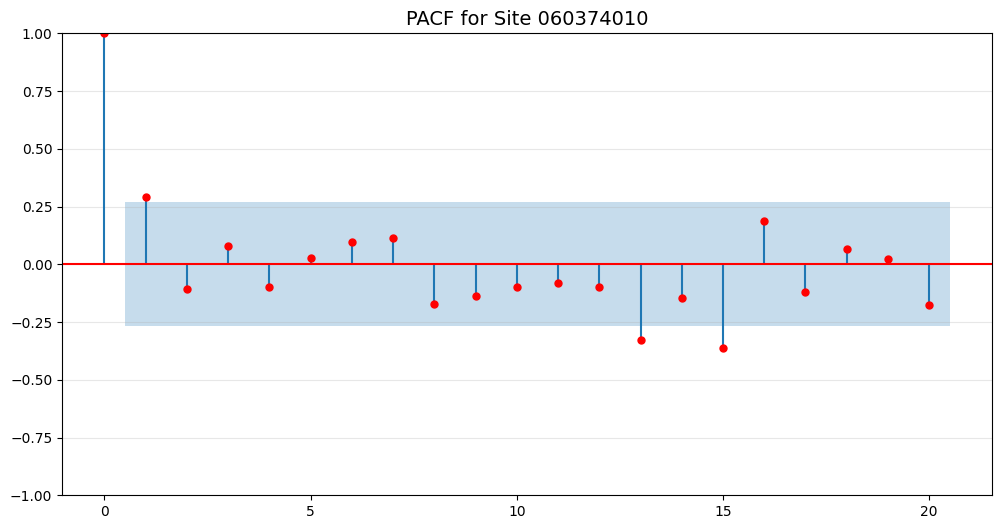

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_pacf

# 1. Load the data
df = pd.read_csv("ad_viz_plotval_data.csv")

# --- DIAGNOSTIC PRINT ---
# This shows you the first 5 unique Site IDs so you can verify the format
print("First 5 Site IDs found in file:", df["Site ID"].unique()[:5])

# 2. Pre-process
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# UNIVERSAL MATCHING:
# We convert everything to strings and remove '.0' if it exists (common with floats)
target_id = "060374010"
df["Site ID_Str"] = df["Site ID"].astype(str).str.replace(".0", "", regex=False).str.strip()

# We check for the ID with OR without the leading zero just to be safe
site_df = df[df["Site ID_Str"].isin([target_id, target_id.lstrip('0')])].copy()
site_df = site_df.sort_values("Date")

# 3. Resample
weekly = (
    site_df.set_index("Date")["Daily Mean PM2.5 Concentration"]
    .resample("W")
    .mean()
    .dropna()
)

print(f"Number of weekly data points found: {len(weekly)}")

# 4. Plotting logic
if len(weekly) < 2:
    print("Still no data. Please check the 'First 5 Site IDs' printed above and update target_id.")
else:
    # Set lags to 20, or half the data size, whichever is smaller
    max_lags = min(20, (len(weekly) // 2) - 1)

    fig, ax = plt.subplots(figsize=(12, 6))
    # 'yw' method avoids the previous error
    plot_pacf(weekly, lags=max_lags, ax=ax, method='yw', color='red')

    plt.title(f"PACF for Site {target_id}", fontsize=14)
    plt.grid(axis='y', alpha=0.3)
    plt.show()

p = 1, d = 0, q = 0

We are so lucky we have such clean data 😎

In [ ]:
# ==============================================================================
# PHASE 1: PREP THE AIR QUALITY (PM2.5) DATA
# Goal: Get a clean daily average of PM2.5 for our specific LA site,
# and create a "tomorrow" column so our model has a target to predict.
# ==============================================================================

# 1. Load the data: Read the EPA CSV file ('ad_viz_plotval_data.csv').
# HINT: Use pd.read_csv()
# [Write your code here]
df = pd.read_csv("ad_viz_plotval_data.csv")


# 2. Fix the dates: Convert the 'Date' column into proper pandas datetime objects.
# HINT: Use pd.to_datetime(..., errors='coerce')
# [Write your code here]

# datecol = pd.to_datetime(df['Date'], errors = 'coerce')
# datecol
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# 3. Filter for LA
# Clean up the ID column as a string, filter the dataframe to only include
# rows with this site, and sort them chronologically.
# HINT: Use .astype(str), .str.replace(), .isin(), and .sort_values()
# [Write your code here]
#hopefully cleaning IDs, all IDs are strings and no bad formatting
df['Site ID'] = df['Site ID'].astype(str)
df['Site ID'] = df['Site ID'].str.replace('-', '', regex=False)
#filtering for LA county (there are lots of potential IDs)
la_df = df[df['County'] == 'Los Angeles']
la_df = la_df.sort_values('Date')
#la_sites = ['060370016', '060371302', '060371103'] #incomplete


# 4. Get the daily average: Set the Date as the index, resample the data
# to a daily frequency, calculate the mean, and drop any missing days.
# HINT: Use .set_index(), .resample('D').mean(), and .dropna()
# [Write your code here]

la_daily = la_df.set_index('Date')[['Daily Mean PM2.5 Concentration', 'Site Latitude', 'Site Longitude']].resample('D').mean().dropna()
la_daily = la_daily.reset_index().rename(columns={
    "Date" : "date",
    "Site Latitude": "latitude",
    "Site Longitude": "longitude"
})

# 5. Create the target variable: Reset the index so 'date' is a normal column.
# Then, create a new column called 'pm25_tomorrow' by shifting the pm25 data
# backward by exactly one day.
# HINT: Use .reset_index() and .shift(-1)
# [Write your code here]

la_daily = la_daily.reset_index().rename(columns = {"Date" : "date"})
la_daily['pm25'] = la_daily['Daily Mean PM2.5 Concentration']


# ==============================================================================
# PHASE 2: PREP THE WEATHER DATA
# Goal: Load the Open-Meteo data and make sure the dates match the exact
# format of our PM2.5 dates.
# ==============================================================================

# 1. Load the data: Read the LA weather history CSV ('la_weather_history.csv').
# [Write your code here]

df2 = pd.read_csv('la_weather_history.csv')
df2

# 2. Format the dates: Convert the date column to datetime.
# CRUCIAL STEP: Strip the timezone information (UTC) away and normalize the
# time so it perfectly matches the EPA dates. If we don't do this, the merge fails!
# HINT: Use .dt.tz_localize(None) and .dt.normalize()
# [Write your code here]

df2['date'] = pd.to_datetime(df2['date']).dt.tz_localize(None).dt.normalize()

# ==============================================================================
# PHASE 3: PREP THE FIRE DATA
# Goal: Condense the raw MODIS fire data so we just have one row per day,
# showing the total number of fires and the total fire intensity.
# ==============================================================================

# 1. Load the data: Read the MODIS fire archive CSV ('fire_archive_M-C61_716953.csv').
# [Write your code here]

df3 = pd.read_csv("fire_archive_M-C61_716953.csv")
df3

# 2. Format the dates: Convert the 'acq_date' (acquisition date) to datetime
# and normalize it.
# [Write your code here]

df3['acq_date'] = pd.to_datetime(df3['acq_date']).dt.tz_localize(None).dt.normalize()


# 3. Group by day: Calculate daily fire totals and intensity
#    - fire_count: The total number of fires (use 'size').
#    - fire_frp_sum: The total sum of the Fire Radiative Power (use 'sum').
# HINT: Use .groupby().agg( fire_count=('acq_date', 'size'), fire_frp_sum=('frp', 'sum') )
# [Write your code here]

# firecount = df3.size()
# fire_frp_sum = df3['frp'].sum

fire_daily = df3.groupby('acq_date').agg(fire_count=('acq_date', 'size'),fire_frp_sum=('frp', 'sum'))



# 4. Clean up: Reset the index and rename 'acq_date' to 'date' so it
# matches our other tables.
# HINT: Use .reset_index() and .rename()
# [Write your code here]
#DEF NOT CORRECT YET
fire_daily = fire_daily.reset_index().rename(columns={'acq_date' : 'date'})
fire_daily['date'] = fire_daily['date'] + pd.DateOffset(years=1)

# ==============================================================================
# PHASE 4: THE GRAND MERGE
# Goal: Snap all three datasets together like Lego bricks using the `date` column.
# ==============================================================================

# 1. Merge Air & Weather: Combine the PM2.5 dataframe and the Weather dataframe.
# First, let's make sure our columns are named correctly for the merge
# We only want rows where the dates exist in BOTH tables.

# HINT: Use pd.merge(..., on='date', how='inner')
# [Write your code here]
#print(la_daily.columns)
#print(weather_df.columns)

dfMerge1 = pd.merge(la_daily, df2, on='date', how='inner')


# 2. Merge in the Fires: Combine that result with the daily fires dataframe.
# CRUCIAL STEP: Use a 'left' join! Most days in LA don't have fires. An 'inner'
# join here would delete every single day of the year without a forest fire.
# HINT: Use pd.merge(..., on='date', how='left')
# [Write your code here]

dfMerge2 = pd.merge(dfMerge1, fire_daily, on='date', how='left')

# 3. Fill the blanks: Because we did a left join, days without fires will say
# 'NaN' (Not a Number) for the fire stats. Replace those NaNs with 0.
# HINT: Use .fillna(0)
# [Write your code here]
dfMerge2 = dfMerge2.fillna(0)
dfMerge2

# 4. Final clean & export
# Create the 'fire_frp_sum_tomorrow' target for your SARIMAX model.
# [Write your code here]
dfMerge2['fire_frp_sum_tomorrow'] = dfMerge2['fire_frp_sum'].shift(-1)


# Keep only the columns you specified for the final output
# [Write your code here]
dfMerge2 = dfMerge2[['date', 'fire_frp_sum', 'fire_frp_sum_tomorrow', 'wind_speed', 'wind_dir', 'pm25', 'latitude', 'longitude']]

# Drop the last row (it won't have a 'tomorrow' value) and save
# HINT: Use .dropna() and .to_csv('master_merged_data.csv', index=False)
# [Write your code here]

dfMerge2 = dfMerge2.dropna()
dfMerge2.to_csv('master_merged_data.csv', index=False)
dfMerge2

# OUTPUT SHOULD BE LIKE

# date          fire_frp_sum  fire_frp_sum_tomorrow  wind_speed  wind_dir  pm25
# 0 2025-01-01           0.0                  450.2    3.885665  327.339   50.1
# 1 2025-01-02         450.2                  120.5    3.438895  328.815   18.2
# 2 2025-01-03         120.5                    0.0    9.292255  180.320   21.3

# fire_frp_sum is simply the total heat intensity of all fires detected in the Los Angeles area for a single day.
# fire_frp_sum_tomorrow is just fire_frp_sum shifted the data backward by one day

,date,fire_frp_sum,fire_frp_sum_tomorrow,wind_speed,wind_dir,pm25,latitude,longitude
0,2025-01-01,1399.4,4478.8,3.885665,327.339050,35.372222,34.086631,-118.237153
1,2025-01-02,4478.8,886.1,3.438895,328.815160,18.800000,34.111249,-118.244422
2,2025-01-03,886.1,3397.8,9.292255,180.320070,19.581818,34.111249,-118.244422
3,2025-01-04,3397.8,3088.0,10.182337,114.594770,21.906667,34.095036,-118.241187
4,2025-01-05,3088.0,997.6,5.318383,351.869960,13.633333,34.090283,-118.240779
...,...,...,...,...,...,...,...,...
360,2025-12-26,7471.6,2474.8,15.368669,100.977585,3.387500,34.182756,-118.260718
361,2025-12-27,2474.8,1768.5,7.056826,8.936938,7.233333,34.139529,-118.250751
362,2025-12-28,1768.5,12937.0,7.168430,356.071780,8.888889,34.139529,-118.250751
363,2025-12-29,12937.0,23825.1,5.994297,178.646820,5.844444,34.139529,-118.250751


In [ ]:
!pip install pydeck

                                      SARIMAX Results                                      
Dep. Variable:                        fire_frp_sum   No. Observations:                  365
Model:             SARIMAX(1, 0, 0)x(1, 0, [1], 4)   Log Likelihood               -4280.771
Date:                             Sun, 05 Apr 2026   AIC                           8575.542
Time:                                     20:27:29   BIC                           8602.841
Sample:                                          0   HQIC                          8586.391
                                             - 365                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
wind_speed  1627.3852    840.490      1.936      0.053     -19.945    3274.715
wind_dir      21.5084     5

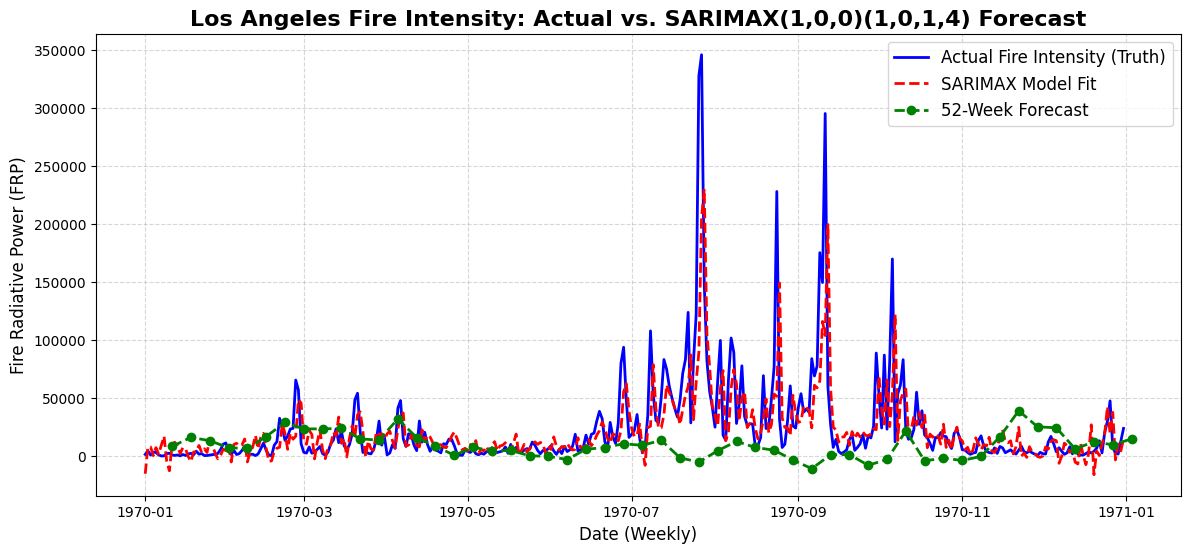

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt
import pandas as pd

# The 'weekly' Series from the previous cell is the correctly preprocessed data.
# site_df is empty, so we should use weekly.
# Removing lines that attempt to process the empty site_df.
n = 52
# Define the parameters we found from our ADF, ACF, and PACF tests
p = 1
d = 0
q = 0
#new sarimax parameters for seasonality (monthly cycle bc of our dataset size)
P, D, Q, m = 1, 0, 1, 4

x_clean = dfMerge2
# Specific (p, d, q) order
# y would be intensity of fires
# x would be fire_frp_sum from wind dir and 2.5 stuff
exog = dfMerge2[["wind_speed", "wind_dir", "pm25"]]
model = SARIMAX(
    dfMerge2["fire_frp_sum"],
    exog=exog,
    order=(p, d, q),
    seasonal_order=(P, D, Q, m)
)

# Fit the model (This is where the math happens and it learns the patterns)
fitted_model = model.fit()

# Summary report
print(fitted_model.summary())

# Get the model's predictions for the data it just trained on
predictions = fitted_model.predict(start=0, end=len(x_clean)-1)

# Forecast n weeks into the FUTURE (the unknown!)
future_exog = x_clean[["wind_speed", "wind_dir", "pm25"]].iloc[-52:].copy()

# Reassign index to the actual future dates
last_date = x_clean.index[-1]
future_dates = pd.date_range(start=last_date, periods=53, freq='W')[1:]
future_exog.index = future_dates

future_forecast = fitted_model.forecast(steps=n, exog=future_exog)
future_forecast.index = future_dates


#future_forecast = fitted_model.forecast(steps=n, exog = future_exog)

# Plot the actual historical data (Blue line)
plt.figure(figsize=(14, 6))
plt.plot(x_clean.index, x_clean["fire_frp_sum"], label='Actual Fire Intensity (Truth)', color='blue', linewidth=2)

# Plot the model's predictions over the historical data (Red dashed line)
plt.plot(x_clean.index, predictions, label='SARIMAX Model Fit', color='red', linestyle='--', linewidth=2)


# Future forecast (now plotted too!)
plt.plot(future_forecast.index, future_forecast.values,
         label='52-Week Forecast', color='green', linestyle='--', linewidth=2, marker='o')

# Make it look pretty
plt.title('Los Angeles Fire Intensity: Actual vs. SARIMAX(1,0,0)(1,0,1,4) Forecast', fontsize=16, fontweight='bold')
plt.xlabel('Date (Weekly)', fontsize=12)
plt.ylabel('Fire Radiative Power (FRP)', fontsize=12)
plt.legend(loc='upper right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [ ]:
# Build future dates starting from the day AFTER your last observation
# last_date = x_clean.index[-1]  # gets the last date in your data
# future_dates = pd.date_range(start=last_date, periods=5, freq="W")[1:]  # [1:] skips the last known date
# print(future_dates)

future_dates = pd.date_range(start='2025-12-25', periods=53, freq='W')[1:]

# Now build and export the forecast dataframe
forecast_df = pd.DataFrame({
    "date": future_dates,
    "forecasted_pm25": future_forecast.values
})

forecast_df.to_csv("sarimax_forecast.csv", index=False)
print(forecast_df)

pd.date_range(start=last_date, periods=5)


         date  forecasted_pm25
0  2026-01-04      8289.748669
1  2026-01-11     16109.726499
2  2026-01-18     13228.361154
3  2026-01-25      7174.923383
4  2026-02-01      6517.661600
5  2026-02-08     16840.140383
6  2026-02-15     28943.726476
7  2026-02-22     23418.033089
8  2026-03-01     23416.663135
9  2026-03-08     23866.398391
10 2026-03-15     14820.429105
11 2026-03-22     13692.530152
12 2026-03-29     32023.930504
13 2026-04-05     15872.378526
14 2026-04-12      8545.264698
15 2026-04-19       650.620747
16 2026-04-26      7616.378706
17 2026-05-03      4447.939374
18 2026-05-10      4805.092373
19 2026-05-17       264.137647
20 2026-05-24      -265.633103
21 2026-05-31     -2993.798130
22 2026-06-07      5889.328782
23 2026-06-14      7293.533371
24 2026-06-21     10608.337251
25 2026-06-28      9220.097033
26 2026-07-05     13636.928748
27 2026-07-12     -1517.555982
28 2026-07-19     -5226.105957
29 2026-07-26      4591.365472
30 2026-08-02     12675.060062
31 2026-

DatetimeIndex(['1970-01-01 00:00:00.000000364',
               '1970-01-02 00:00:00.000000364',
               '1970-01-03 00:00:00.000000364',
               '1970-01-04 00:00:00.000000364',
               '1970-01-05 00:00:00.000000364'],
              dtype='datetime64[ns]', freq='D')

In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 32.3 MB/s eta 0:00:00


In [ ]:
!pip install streamlit_folium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.2/529.2 kB 5.5 MB/s eta 0:00:00


## Dashboard

The interactive Streamlit dashboard lives in  at the repo root.
Run it with . See the README for details.